## <span style="color:orange">**Respuestas al cliente**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df_loads_trips = pd.read_csv("../datos_transformados/df_loads_trips.csv", sep = ',')
df_rutas = pd.read_csv("../datos_transformados/df_rutas.csv")
df_empleados = pd.read_csv("../datos_transformados/df_empleados.csv")
df_camiones = pd.read_csv("../datos_transformados/df_camiones.csv", index_col=False)
df_camiones_mantenimiento = pd.read_csv("../datos_transformados/df_camiones_mantenimiento.csv", index_col=False)
df_clientes = pd.read_csv("../datos_transformados/df_clientes.csv", index_col=False)

- <span style="color:orange">*1. Los 10 empleados que más viajes han realizado*

In [2]:
top_10_empleados = (
    df_loads_trips.groupby("driver_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_10_empleados

,driver_id,0
0,DRV00019,749
1,DRV00066,737
2,DRV00108,735
3,DRV00059,729
4,DRV00087,725
5,DRV00051,723
6,DRV00149,721
7,DRV00078,717
8,DRV00016,712
9,DRV00142,711


- <span style="color:orange">*2. Los 10 empleados que más beneficios han reportado a la empresa*

In [3]:
top_10_empleados = (
    df_loads_trips.groupby("driver_id")["total_revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_10_empleados

,driver_id,total_revenue
0,DRV00051,2001643.62
1,DRV00108,1996901.06
2,DRV00059,1990293.79
3,DRV00016,1976713.01
4,DRV00019,1961566.52
5,DRV00149,1959289.10
6,DRV00127,1956679.03
7,DRV00147,1948218.86
8,DRV00085,1918615.02
9,DRV00087,1915458.77


- *<span style="color:orange">3. Los 10 empleados que más tiempo han estado en la carretera*

In [4]:
top_10_empleados = (
    df_loads_trips.groupby("driver_id")['actual_duration_hours']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_10_empleados

,driver_id,actual_duration_hours
0,DRV00051,18841.0
1,DRV00108,18830.8
2,DRV00059,18620.5
3,DRV00019,18544.1
4,DRV00149,18394.5
5,DRV00127,18273.5
6,DRV00016,18209.5
7,DRV00147,18137.7
8,DRV00085,18082.2
9,DRV00087,18024.8


- *<span style="color:orange">4. Qué rutas aportan mayores beneficios*

In [5]:
top_10_rutas = (
    df_loads_trips.groupby("route_id")['total_revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_10_rutas_con_nombre = top_10_rutas.merge(
    df_rutas[['route_id','origin_city', 'destination_city']],
    on='route_id', 
    how='left'
)

top_10_rutas_con_nombre

,route_id,total_revenue,origin_city,destination_city
0,RTE00016,9281621.77,Philadelphia,Seattle
1,RTE00012,8970770.01,Phoenix,Philadelphia
2,RTE00044,8729005.02,Charlotte,Portland
3,RTE00046,8626434.92,Columbus,Los Angeles
4,RTE00042,8280973.43,Charlotte,Seattle
5,RTE00048,8264044.90,Columbus,Portland
6,RTE00029,8100477.77,Seattle,Charlotte
7,RTE00003,6643074.28,Chicago,Los Angeles
8,RTE00021,6619729.94,Houston,Portland
9,RTE00025,6600156.13,Miami,Seattle


<span style="color:orange">--------------------------------------------------------------------

- *<span style="color:orange">5. Qué camiones tienen un mantenimiento más costoso*

In [6]:
top_10_camiones_costosos = (
    df_camiones_mantenimiento.groupby("truck_id")['total_cost']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_10_camiones_costosos_marca = top_10_camiones_costosos.merge(
    df_camiones[['truck_id','make', 'model_year']],
    on='truck_id', 
    how='left'
)

top_10_camiones_costosos_marca

,truck_id,total_cost,make,model_year
0,TRK00003,90161.42,Peterbilt,2018
1,TRK00073,76573.99,Mack,2016
2,TRK00081,73892.72,Freightliner,2018
3,TRK00099,73231.77,Freightliner,2015
4,TRK00014,71801.82,International,2015
5,TRK00075,71073.64,Mack,2015
6,TRK00118,71005.77,Freightliner,2015
7,TRK00026,70708.48,International,2021
8,TRK00044,69825.23,Volvo,2015
9,TRK00038,68989.14,International,2015


- <span style="color:orange">*6. Qué perfil de cliente tiene la empresa. Tipos de contrato, cargas que contratan, etc*

<span style="color:orange">Aquí sacamos algunas de las métricas para el cliente:

- <span style="color:orange">Tipo de cliente: Vemos que hay una ligera ventaja entre los clientes que tienen un contrato tipo Contract, aunque no es muy significativa.
- <span style="color:orange">Tipo de crédito: los clientes prefieren los créditos a 30 o 60 días por encima de los 15 o 45 días.
- <span style="color:orange">Tipo de carga: Las primeras posiciones para el tipo de carga son Automotive, Food/Beverage o Retail, en la última posición con un 12% está General.
- <span style="color:orange">Estado de la cuenta: Aunque hay clientes inactivos, la mayoría (84%) siguen teniendo la cuenta en activo, buen dato para la empresa.


In [7]:
# df_clientes.shape
df_clientes.columns

Index(['customer_id', 'customer_name', 'customer_type', 'credit_terms_days',
       'primary_freight_type', 'account_status', 'contract_start_date',
       'annual_revenue_potential'],
      dtype='object')

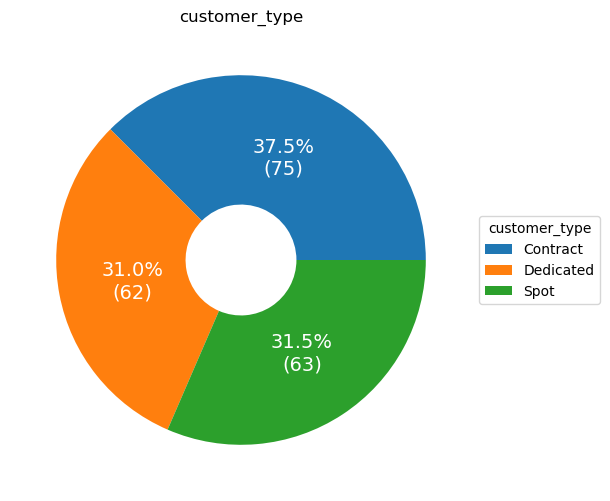

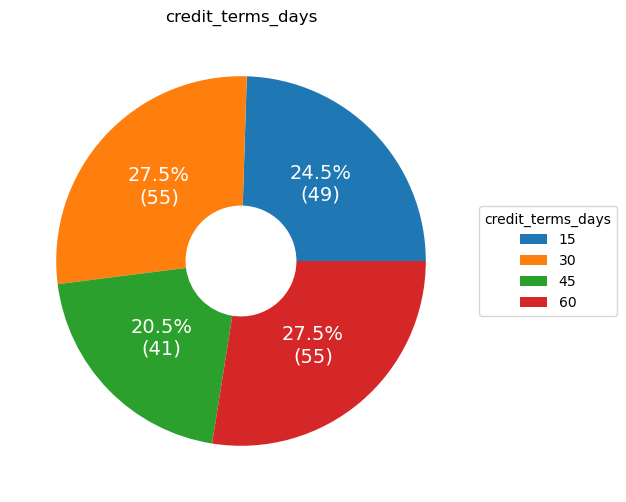

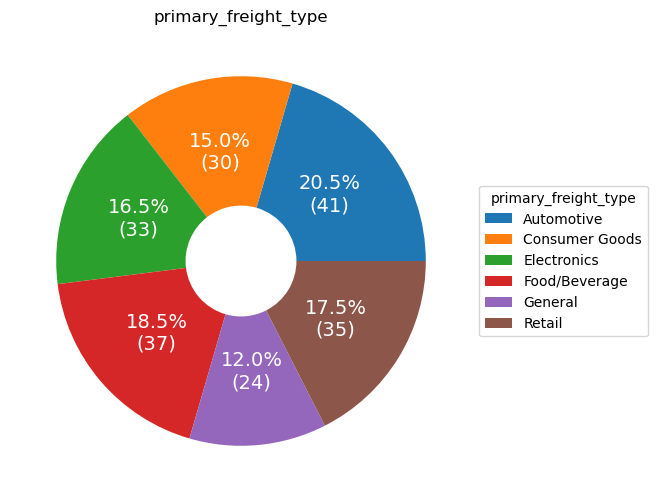

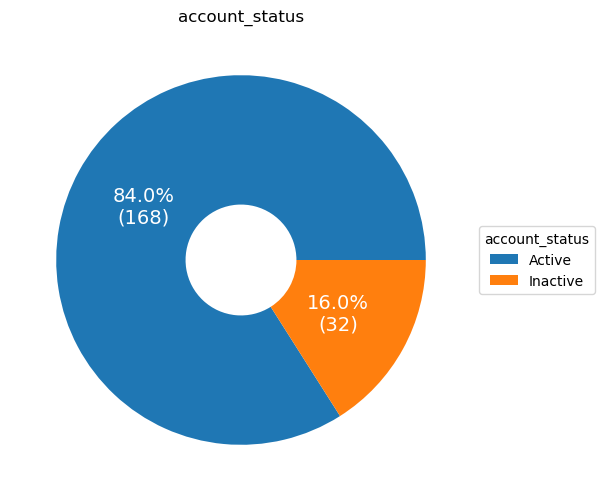

In [8]:
columns = ['customer_type', 'credit_terms_days', 'primary_freight_type', 'account_status']

for col in columns:
       # Agrupar los datos por customer_type
       data_grouped = df_clientes.groupby([col]).size().reset_index(name='Count')

       # plot
       fig, ax = plt.subplots(figsize=(10, 6), subplot_kw=dict(aspect="equal"))

       data = data_grouped['Count'].tolist()
       ingredients = data_grouped[col].tolist()

       def func(pct, allvals):
              absolute = int(np.round(pct/100.*np.sum(allvals)))
              return f"{pct:.1f}%\n({absolute:d})"

       wedges, texts, autotexts = ax.pie(
       data,
       autopct=lambda pct: func(pct, data),
       wedgeprops={'width': 0.7},
       textprops=dict(color="w")
       )

       ax.legend(
       wedges, ingredients,
       title=col,
       loc="center left",
       bbox_to_anchor=(1, 0, 0.5, 1)
       )

       plt.setp(autotexts, size=14, weight="light")

       ax.set_title(f"{col}")

       plt.show()

- <span style="color:orange">Tipo de carga: Hay bastante equilibrio entre los dos tipos de carga.

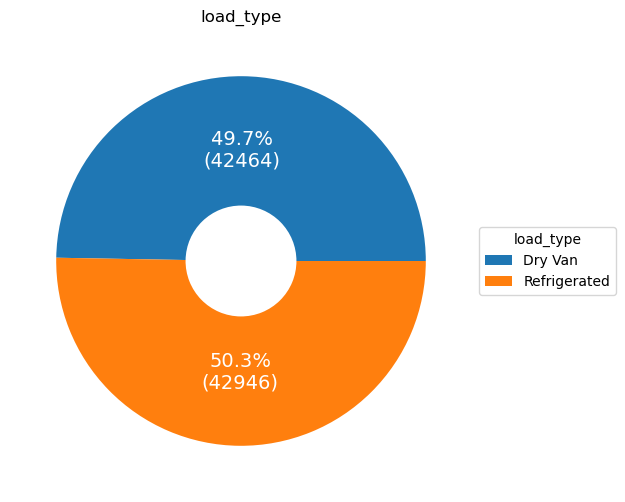

In [9]:
cargas_contratadas = (
    df_loads_trips[df_loads_trips["customer_id"].isin(df_clientes['customer_id'])]
)
cargas_contratadas

# Agrupar los datos por customer_type
data_grouped = cargas_contratadas.groupby(['load_type']).size().reset_index(name='Count')

# plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw=dict(aspect="equal"))

data = data_grouped['Count'].tolist()
ingredients = data_grouped['load_type'].tolist()

def func(pct, allvals):
       absolute = int(np.round(pct/100.*np.sum(allvals)))
       return f"{pct:.1f}%\n({absolute:d})"

wedges, texts, autotexts = ax.pie(
data,
autopct=lambda pct: func(pct, data),
wedgeprops={'width': 0.7},
textprops=dict(color="w")
)

ax.legend(
wedges, ingredients,
title='load_type',
loc="center left",
bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=14, weight="light")

ax.set_title('load_type')

plt.show()

- <span style="color:orange">*7. Qué cliente es el que más abandona la empresa*

(Después de un pequeño análisis, ya que hay nombres de clientes repetidos, hemos confirmado que son clientes distintos, así que nos basaremos en el ID de estos para identificarlos y que no haya confusiones)

In [10]:
df_clientes.columns

Index(['customer_id', 'customer_name', 'customer_type', 'credit_terms_days',
       'primary_freight_type', 'account_status', 'contract_start_date',
       'annual_revenue_potential'],
      dtype='object')

In [11]:
clientes_inactivos = df_clientes[df_clientes['account_status'] == 'Inactive']
# Nombres de los clientes inactivos
clientes_inactivos['customer_name'].unique()

array(['Metro Wholesale', 'American Logistics', 'XYZ Wholesale',
       'First Corp', 'Pacific Retail', 'ABC Supply Chain',
       'First Manufacturing', 'Elite Industries', 'Premier Group',
       'First Group', 'Continental Distribution', 'Elite Corp',
       'Metro Group', 'Premier Wholesale', 'First Distribution',
       'Global Logistics', 'Metro Logistics', 'First Logistics',
       'Pacific Corp', 'ABC Wholesale', 'Global Corp',
       'ABC Manufacturing', 'National Distribution', 'Superior Retail',
       'Premier Retail', 'National Foods', 'Pacific Supply Chain',
       'Global Group', 'Elite Distribution', 'XYZ Foods'], dtype=object)

<span style="color:orange">Vamos a buscar a ver si hay alguna diferencia entre los activos y los que no

<Axes: xlabel='customer_type', ylabel='Count'>

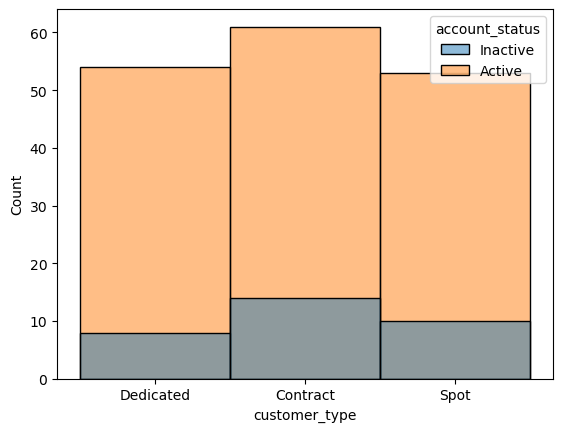

In [12]:
sns.histplot(data=df_clientes, x="customer_type", hue="account_status")

<Axes: xlabel='credit_terms_days', ylabel='Count'>

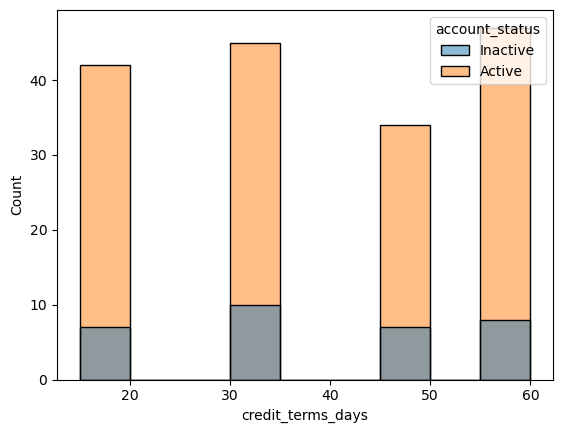

In [13]:
sns.histplot(data=df_clientes, x="credit_terms_days", hue="account_status")

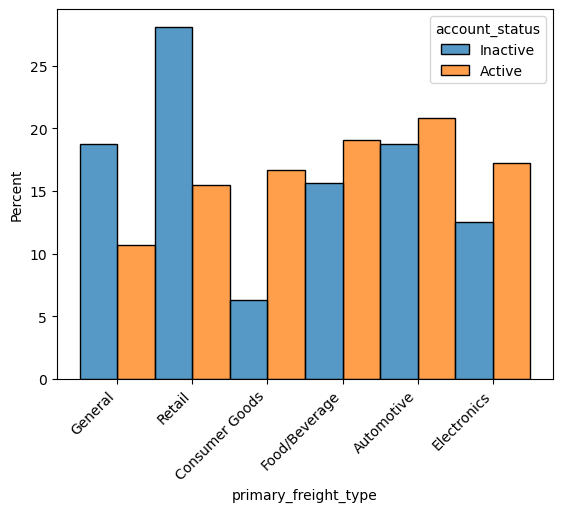

In [14]:
sns.histplot(
    data=df_clientes, 
    x="primary_freight_type", 
    hue="account_status",
    stat="percent", 
    common_norm=False,
    multiple="dodge")
plt.xticks(rotation=45, ha='right')
plt.show()

<span style="color:orange">La conclusión que sacamos aquí es que son los clientes de Retail y General los que parecen abandonar en mayor medida los contratos